# Punto 9 — Pronóstico para los próximos 30 días

Se conservan los órdenes elegidos en el punto 5 y se recalculan sus parámetros con todos los datos disponibles, de 2023 a 2025. Se pronostica **del 1 al 30 de enero de 2026**. Son fechas posteriores al último dato del archivo, no al día en que se redactó el trabajo.

Se usa una ventana de 30 días porque permite observar varias semanas sin extender demasiado el plazo. Para clima y lluvia, estos resultados son una proyección estadística y no reemplazan un pronóstico meteorológico.

La línea central es el valor esperado. La banda del **95%** muestra la incertidumbre del modelo bajo sus supuestos. No es una garantía: puede ser poco confiable si los residuos no cumplen esos supuestos. La banda tampoco incluye toda la incertidumbre de haber elegido y estimado los parámetros.

En temperatura se suma el valor observado de 365 días antes tanto al pronóstico de la diferencia como a sus límites. Esto es válido para estos 30 días porque todos esos valores anteriores son conocidos. No se recortan resultados negativos ni valores de humedad fuera de 0–100%; se registran como limitaciones.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


### Viajes MBTB

,prediccion,inferior95,superior95
fecha,,,
2026-01-01,2540.54,1533.70,3547.38
2026-01-02,2400.39,1382.76,3418.02
2026-01-03,1868.95,840.65,2897.25
2026-01-04,1810.20,771.34,2849.06
2026-01-05,2293.38,1244.06,3342.70
2026-01-06,2482.31,1422.64,3541.99
2026-01-07,2465.36,1395.43,3535.29
2026-01-08,2535.83,1454.84,3616.81
2026-01-09,2395.68,1304.52,3486.85


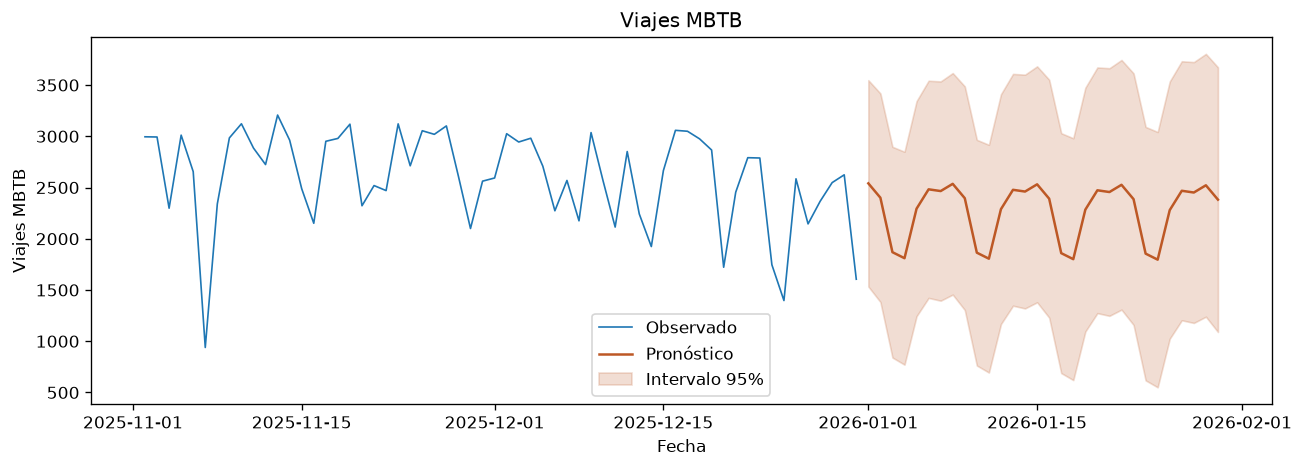

### Temperatura

,prediccion,inferior95,superior95
fecha,,,
2026-01-01,31.01,24.57,37.45
2026-01-02,30.48,22.39,38.58
2026-01-03,27.87,18.94,36.79
2026-01-04,27.86,18.49,37.23
2026-01-05,27.13,17.50,36.75
2026-01-06,27.93,18.17,37.70
2026-01-07,29.42,19.57,39.27
2026-01-08,29.96,20.06,39.85
2026-01-09,29.66,19.74,39.59


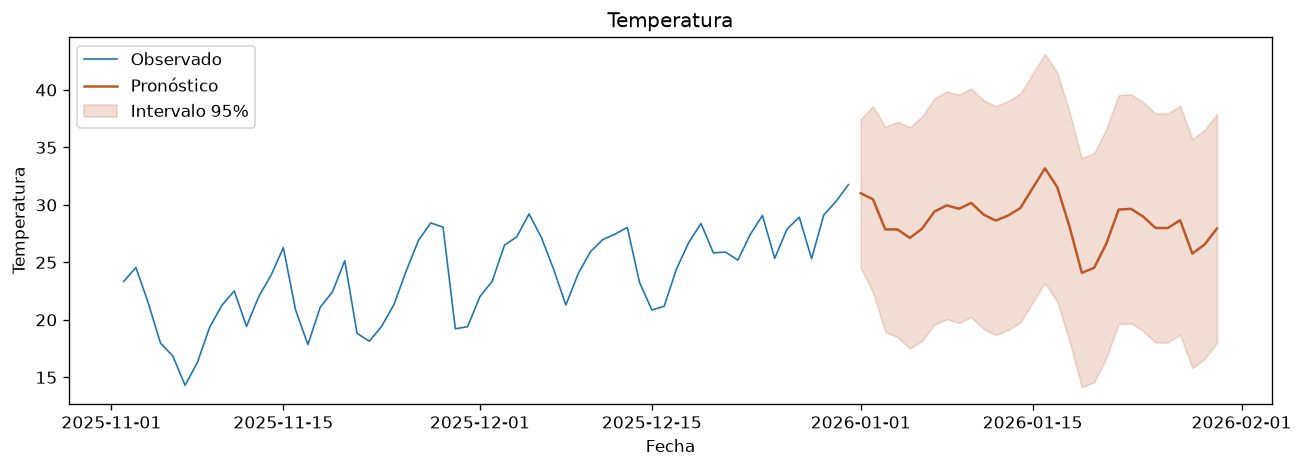

### Humedad

,prediccion,inferior95,superior95
fecha,,,
2026-01-01,50.93,35.31,66.56
2026-01-02,53.83,33.56,74.09
2026-01-03,56.22,33.32,79.11
2026-01-04,58.19,33.67,82.72
2026-01-05,59.82,34.24,85.40
2026-01-06,61.17,34.89,87.44
2026-01-07,62.28,35.54,89.01
2026-01-08,63.19,36.15,90.24
2026-01-09,63.95,36.70,91.21


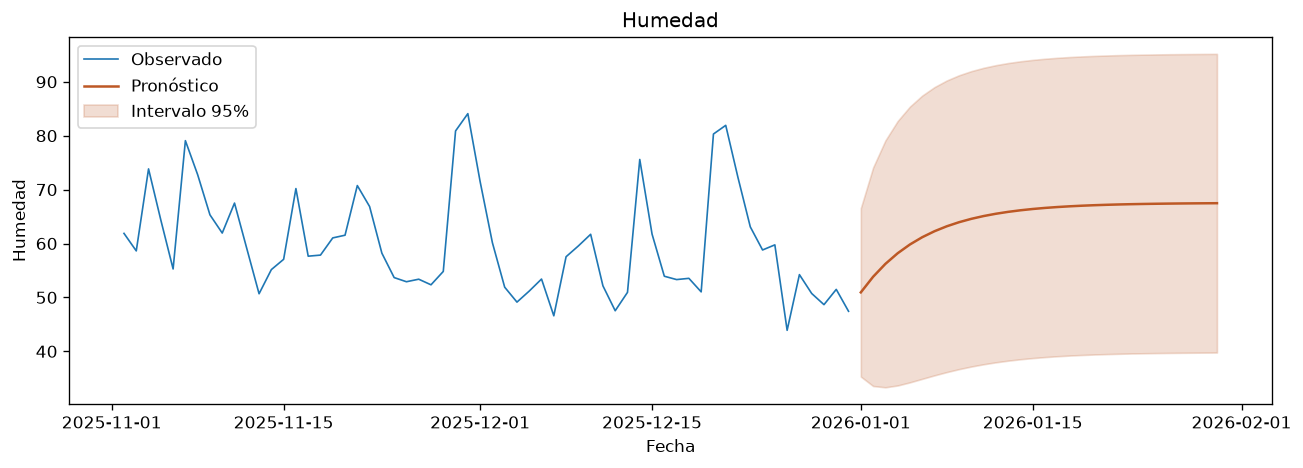

### Precipitación

,prediccion,inferior95,superior95
fecha,,,
2026-01-01,2.34,-15.17,19.85
2026-01-02,2.82,-15.05,20.69
2026-01-03,2.93,-14.96,20.82
2026-01-04,2.96,-14.93,20.85
2026-01-05,2.96,-14.93,20.85
2026-01-06,2.97,-14.92,20.86
2026-01-07,2.97,-14.92,20.86
2026-01-08,2.97,-14.92,20.86
2026-01-09,2.97,-14.92,20.86


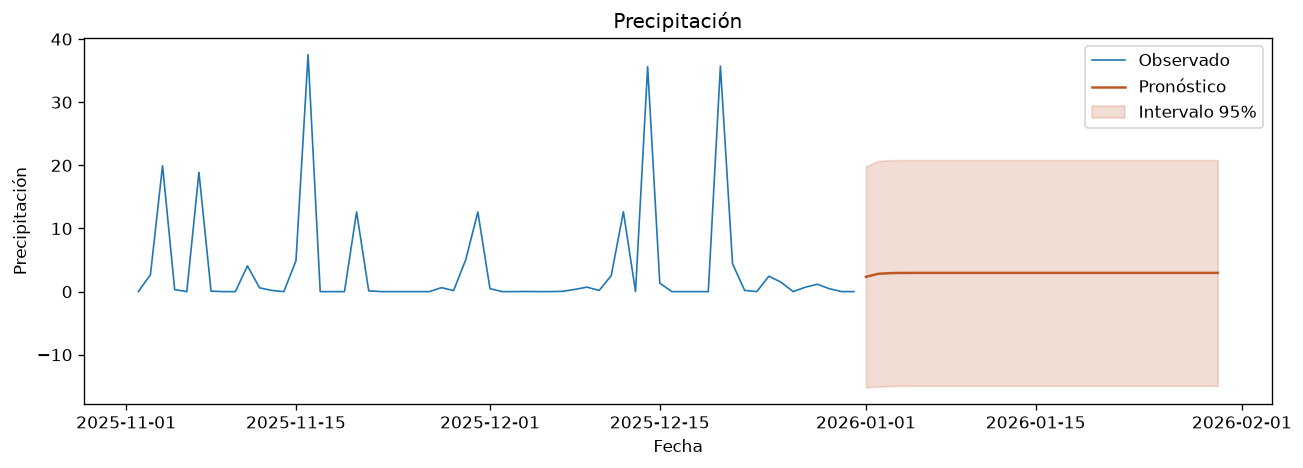

,promedio,minimo,maximo
serie,,,
Humedad,64.37,50.93,67.48
Precipitación,2.94,2.34,2.97
Temperatura,28.69,24.09,33.18
Viajes MBTB,2271.66,1796.06,2540.54


In [2]:
OUT=ROOT/'puntos/punto9';OUT.mkdir(exist_ok=True)
filas=[];alertas=[]
for i,(nombre,s) in enumerate(series.items()):
    fc,r,avisos=intervalo_sarima(s,seleccion[nombre],h=30)
    fc.index.name='fecha';fc['serie']=nombre;filas.append(fc.reset_index())
    invalidos=(fc.prediccion<0) if nombre in ('Viajes MBTB','Precipitación') else ((fc.prediccion<0)|(fc.prediccion>100)) if nombre=='Humedad' else pd.Series(False,index=fc.index)
    alertas.append({'serie':nombre,'predicciones_fuera_rango':int(invalidos.sum()),'advertencias':avisos})
    display(Markdown(f'### {nombre}'))
    display(fc.drop(columns='serie').round(2))
    fig,ax=plt.subplots();ax.plot(s.iloc[-60:],label='Observado',lw=1)
    ax.plot(fc.prediccion,label='Pronóstico',color='#bd5825');ax.fill_between(fc.index,fc.inferior95,fc.superior95,alpha=.2,color='#bd5825',label='Intervalo 95%')
    ax.set(title=nombre,xlabel='Fecha',ylabel=nombre);ax.legend();fig.tight_layout();fig.savefig(OUT/f'pronostico_{i}.png');plt.show();plt.close(fig)
pronosticos=pd.concat(filas,ignore_index=True)
pronosticos.to_csv(OUT/'pronostico_30_dias.csv',index=False)
pd.DataFrame(alertas).to_csv(OUT/'alertas.csv',index=False)
resumen=pronosticos.groupby('serie').agg(promedio=('prediccion','mean'),minimo=('prediccion','min'),maximo=('prediccion','max'))
display(resumen.round(2))


## Conclusión

El pronóstico aprovecha todos los datos disponibles, pero conserva las limitaciones del diagnóstico anterior. No hay valores reales de enero de 2026 en los archivos para calcular su error. El desempeño conocido sigue siendo el de la prueba de 2025; recalcular el modelo con más datos no garantiza una mejora.

**Herramientas y referencias:** Pandas y NumPy para los datos; Matplotlib para gráficos; statsmodels para los modelos y pruebas. Statsmodels developers. (s. f.). [Documentación de series temporales](https://www.statsmodels.org/stable/tsa.html).